In [32]:
import numpy as np
import pandas as pd
import nitools as nit
import nibabel as nib
from nibabel.affines import apply_affine
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.evaluation as ev
import cortico_cereb_connectivity.cio as cio
import cortico_cereb_connectivity.scripts.script_plotting_utils as plu
import Functional_Fusion.dataset as fdata
import Functional_Fusion.atlas_map as am
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.evaluation as ev
import SUITPy as suit

In [33]:
train_ds = 'MDTB'
indx = gl.datasets.index(train_ds)
train_ses = gl.sessions[indx]
add_rest = gl.add_rest[indx]
std_cortex = gl.std_cortex[indx]

In [34]:
# the label
label_img = nib.load(gl.atlas_dir + "/tpl-MNI152NLin6Asym/atl-Platchi5_space-MNI152NLin6Asym_dseg.nii")
label_data = label_img.get_fdata().squeeze()

# atlas
cereb_atlas, cereb_ainf = am.get_atlas('MNISymC3')
hipp_atlas, hipp_ainf = am.get_atlas('Platchi5')

In [35]:
new_data = np.zeros(label_data.shape, dtype=np.uint8)

for label in range(1, 6):

    vox = np.argwhere(label_data == label)
    xyz = apply_affine(label_img.affine, vox)

    left = xyz[:, 0] < 0
    right = xyz[:, 0] > 0

    # 1L, 1R, 2L, 2R, ...
    left_label = 2 * label - 1
    right_label = 2 * label

    new_data[tuple(vox[left].T)] = left_label
    new_data[tuple(vox[right].T)] = right_label

new_label_img = nib.Nifti1Image(
    new_data,
    label_img.affine,
    label_img.header
)

new_label_data = new_label_img.get_fdata().squeeze()

label_vec, labels = hipp_atlas.get_parcel(new_label_img)
names = ['1L', '1R', '2L', '2R', '3L', '3R', '4L', '4R', '5L', '5R']
print(labels)
print(names)

[ 1  2  3  4  5  6  7  8  9 10]
['1L', '1R', '2L', '2R', '3L', '3R', '4L', '4R', '5L', '5R']


In [36]:
config = rm.get_train_config(log_alpha=0,
                                 crossed='half',
                                 type='CondHalf',
                                 cond_num='all',
                                 subj_list='all',
                                 cerebellum='MNISymC3',
                                 parcellation='Icosahedron1002',
                                 train_dataset=train_ds,
                                 method='NNLS',
                                 train_ses=train_ses,
                                 add_rest=add_rest,
                                 std_cortex=std_cortex,
                                 std_cerebellum='global',
                                 cortical_cerebellar_act='ind',
                                 append=False)

In [37]:
subj = rm.get_subj_list('all', train_ds)

# Load the data
HH, info, _ = fdata.get_dataset(gl.base_dir,
                                   train_ds,
                                   sess=train_ses,
                                   subj=subj,
                                   atlas='MNIAsymHippocampus',
                                   type=config["type"])

HH, info_h = rm.prepare_data(HH, info, config)
for i in range(HH.shape[0]):
    if 'std_cortex' in config.keys():
        HH[i,:,:] = rm.std_data(HH[i,:,:], config['std_cortex'])
H = HH.mean(axis=0)

# Load the data
XX, info_x = rm.get_cortical_data(train_ds, train_ses, subj, config)
X = XX.mean(axis=0)

# Load the data
YY, info_y = rm.get_cerebellar_data(train_ds, train_ses, subj, config)
Y = YY.mean(axis=0)

/home/UWO/ashahb7/Github/cortico_cereb_connectivity/cortico_cereb_connectivity/run_model.py:395: RuntimeWarning: invalid value encountered in divide
  return  np.nan_to_num(Y/sc)
/home/UWO/ashahb7/Github/Functional_Fusion/Functional_Fusion/dataset.py:254: RuntimeWarning: Mean of empty slice
  parcel_data[..., i] = fcn(


In [38]:
R, _, _, _ = ev.calculate_reliability(H, info_h)
print(f'Hippocamp reliability: {R:.2f}')
R, _, _, _ = ev.calculate_reliability(X, info_x)
print(f'Cortical reliability: {R:.2f}')
R, _, _, _ = ev.calculate_reliability(Y, info_y)
print(f'Cerebellum reliability: {R:.2f}')

Hippocamp reliability: 0.76
Cortical reliability: 0.93
Cerebellum reliability: 0.86


In [39]:
def calc_corr(H, Y):
    # check NaN
    if np.isnan(H).any():
        print("First input contains NaNs")
    if np.isnan(Y).any():
        print("Second input contains NaNs")

    # should already be zero mean
    A = H - H.mean(axis=0, keepdims=True)
    B = Y - Y.mean(axis=0, keepdims=True)

    A /= np.linalg.norm(A, axis=0, keepdims=True) # should already be norm 1
    B /= np.linalg.norm(B, axis=0, keepdims=True)

    return A.T @ B

In [40]:
# aggregate data within each label
Hl = np.zeros((H.shape[0], len(labels)))
for i, label in enumerate(labels):
    Hl[:, i] = H[:, label_vec == label].mean(axis=1)

In [41]:
corr_hh = calc_corr(H, H)
corr_xx = calc_corr(X, X)
corr_yy = calc_corr(Y, Y)
corr_xy = calc_corr(X, Y)
corr_hy = calc_corr(Hl, Y)
corr_hx = calc_corr(Hl, X)

/localscratch/tmp/ipykernel_261977/1171669134.py:12: RuntimeWarning: invalid value encountered in divide
  A /= np.linalg.norm(A, axis=0, keepdims=True) # should already be norm 1
/localscratch/tmp/ipykernel_261977/1171669134.py:13: RuntimeWarning: invalid value encountered in divide
  B /= np.linalg.norm(B, axis=0, keepdims=True)


/localscratch/tmp/ipykernel_261977/1627791493.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 0.95]);


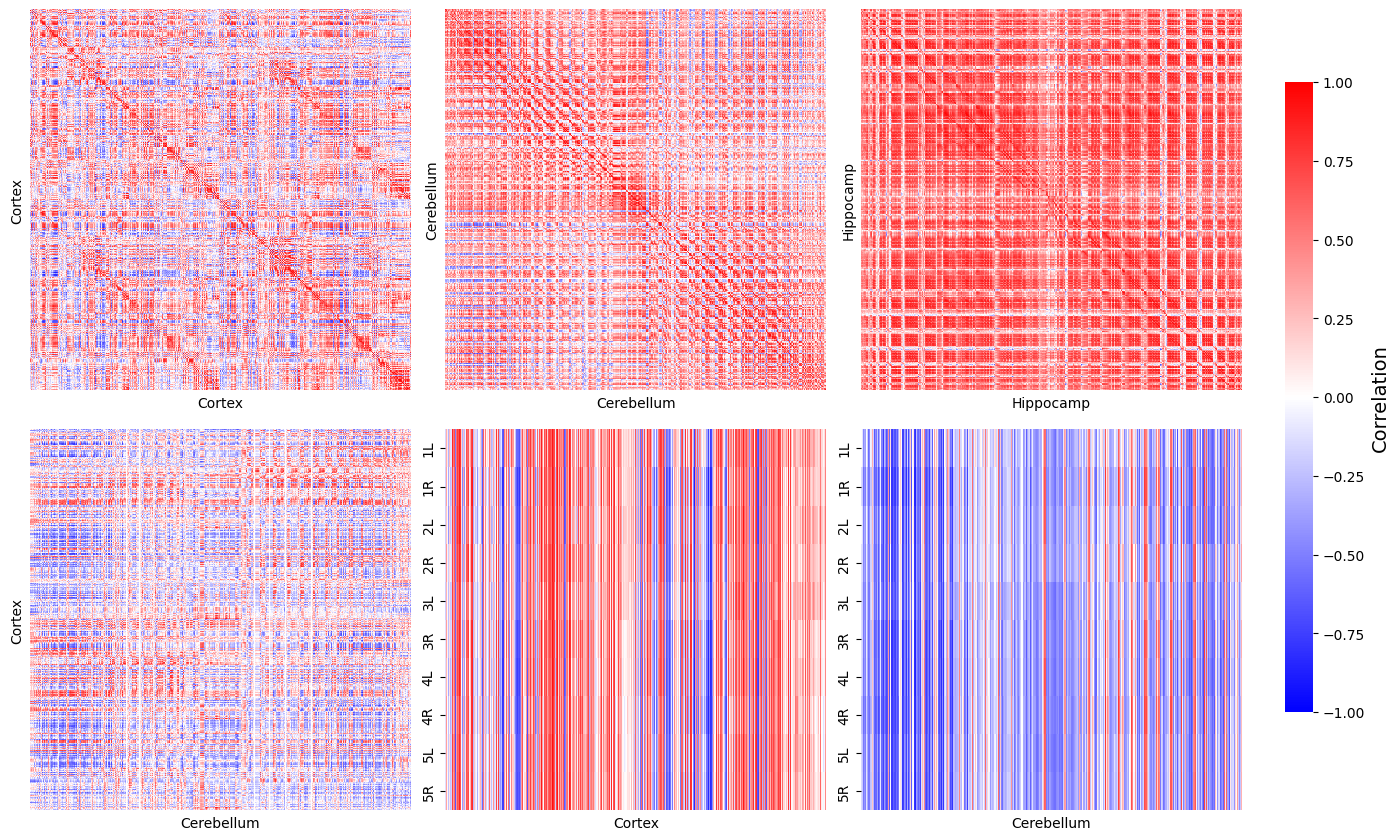

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

sns.heatmap(corr_xx, ax=axes[0,0], cmap='bwr', center=0, xticklabels=False, yticklabels=False, vmin=-1, vmax=1, cbar=False)
# axes[0, 0].set_title('Cortex-Cortex')
axes[0, 0].set_xlabel('Cortex')
axes[0, 0].set_ylabel('Cortex')

sns.heatmap(corr_yy, ax=axes[0,1], cmap='bwr', center=0, xticklabels=False, yticklabels=False, vmin=-1, vmax=1, cbar=False)
# axes[0, 1].set_title('Cerebellum-Cerebellum')
axes[0, 1].set_xlabel('Cerebellum')
axes[0, 1].set_ylabel('Cerebellum')

sns.heatmap(corr_hh, ax=axes[0,2], cmap='bwr', center=0, xticklabels=False, yticklabels=False, vmin=-1, vmax=1, cbar=False)
# axes[0, 2].set_title('Hippocamp-Hippocamp')
axes[0, 2].set_xlabel('Hippocamp')
axes[0, 2].set_ylabel('Hippocamp')

sns.heatmap(corr_xy, ax=axes[1,0], cmap='bwr', center=0, xticklabels=False, yticklabels=False, vmin=-1, vmax=1, cbar=False)
# axes[1, 0].set_title('Cortex-Cerebellum')
axes[1, 0].set_ylabel('Cortex')
axes[1, 0].set_xlabel('Cerebellum')

sns.heatmap(corr_hx, ax=axes[1,1], cmap='bwr', center=0, xticklabels=False, yticklabels=names, vmin=-1, vmax=1, cbar=False)
# axes[1, 1].set_title('Hippocamp-Cortex')
axes[1, 1].set_xlabel('Cortex')

sns.heatmap(corr_hy, ax=axes[1,2], cmap='bwr', center=0, xticklabels=False, yticklabels=names, vmin=-1, vmax=1, cbar_ax=cbar_ax)
# axes[1, 2].set_title('Hippocamp-Cerebellum')
axes[1, 2].set_xlabel('Cerebellum')

for ax in axes.flat:
    ax.set_box_aspect(1)

cbar_ax.set_ylabel('Correlation', fontsize=14)
fig.tight_layout(rect=[0, 0, 0.9, 0.95]);

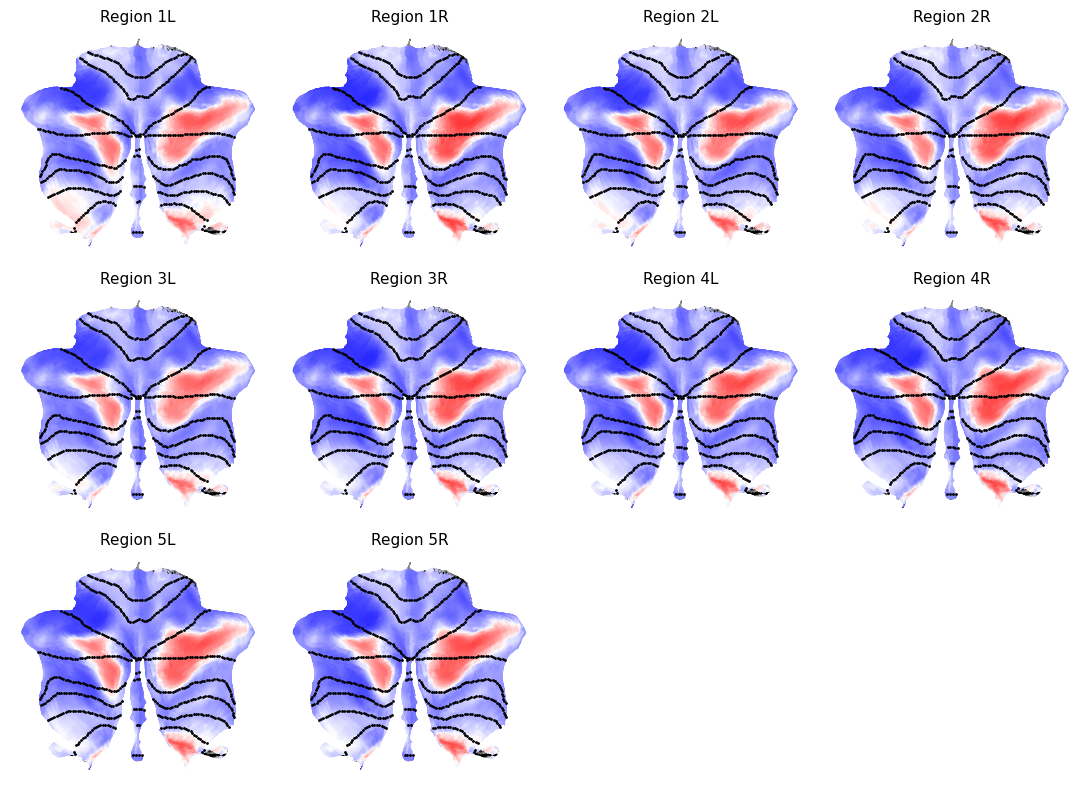

In [43]:
fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for i, (label, name) in enumerate(zip(labels, names)):
    corr_vec = corr_hy[i, :]
    nifti_image = cereb_atlas.data_to_nifti(corr_vec)
    data = suit.vol_to_surf(nifti_image, space='MNISymC')

    plt.subplot(3, 4, i+1)
    suit.flatmap.plot(data, cmap='bwr', new_figure=False, cscale=[-1, 1])
    plt.title(f'Region {name}', fontsize=11)

plt.subplot(3, 4, 11).axis('off')
plt.subplot(3, 4, 12).axis('off')
plt.tight_layout();

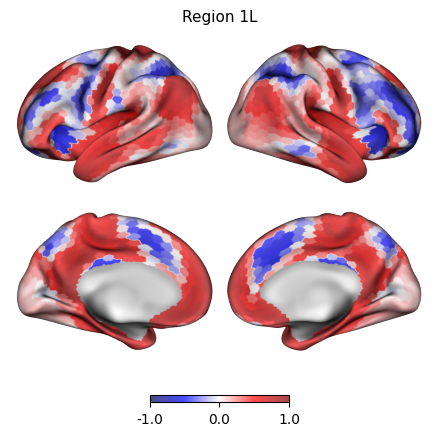

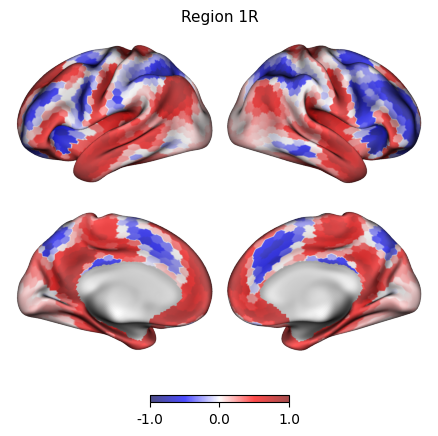

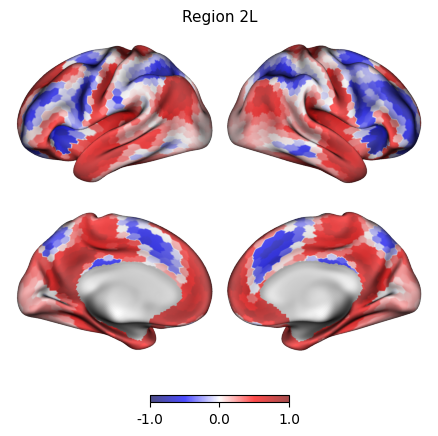

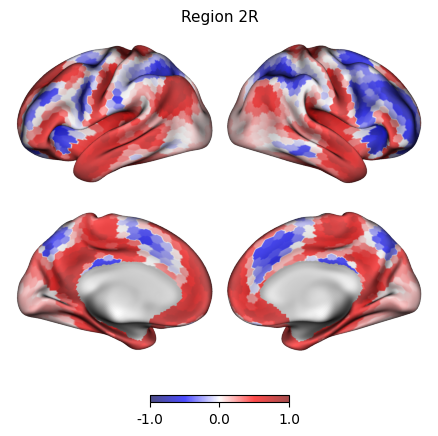

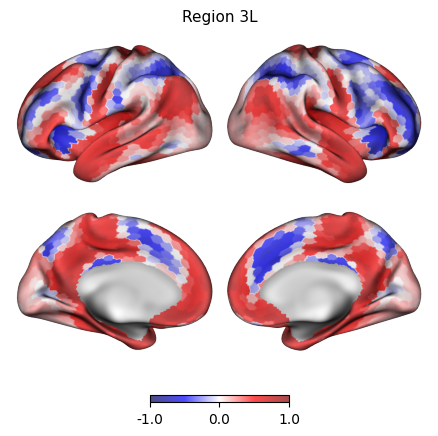

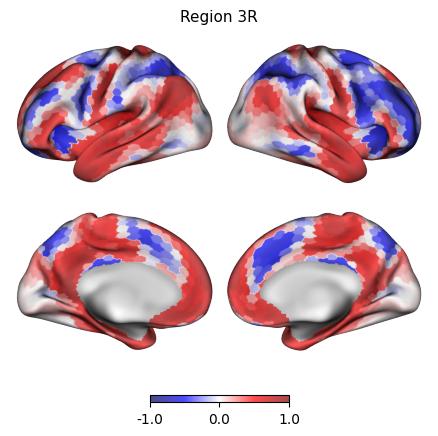

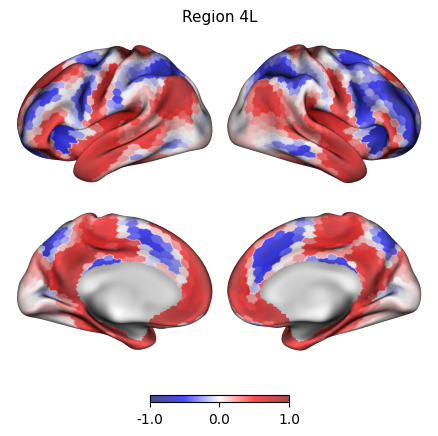

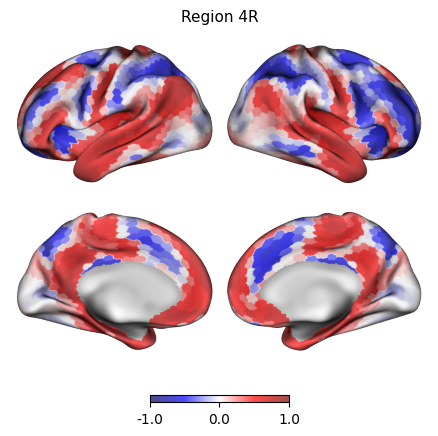

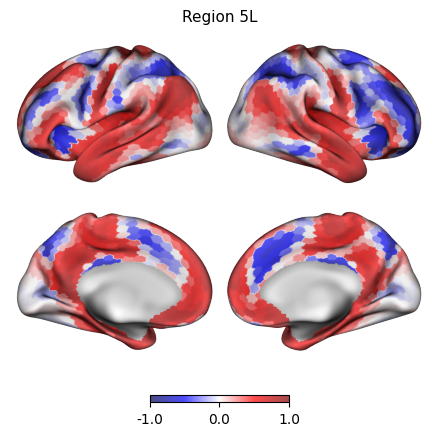

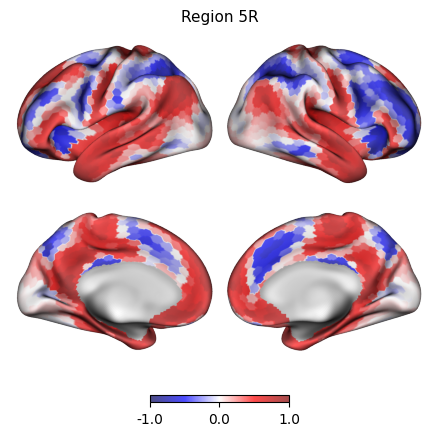

<Figure size 640x480 with 0 Axes>

In [ ]:
label_fs = [gl.atlas_dir + f"/tpl-fs32k/Icosahedron1002.{hemi}.label.gii" for hemi in ["L", "R"]]

for i, (label, name) in enumerate(zip(labels, names)):
    corr_vec = corr_hx[i, :]
    corr_vec = corr_vec[None, :]
    cifti_corr = cio.model_to_cifti(corr_vec, src_roi=label_fs)
    plu.plot_cortex_map(cifti_corr, cmap='seismic', cscale=[-1, 1], alpha=0.7, zero_transparent=False)
    plt.title(f'Region {name}', fontsize=11)
    plt.show()